In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix




In [2]:
df = pd.read_csv("IMDB_Dataset.csv")  # update path if needed
df = df[["review", "sentiment"]].dropna()

# Convert sentiment to 0/1
df["label"] = df["sentiment"].str.lower().map({"negative": 0, "positive": 1})

# Safety check
print(df.head())
print(df["sentiment"].value_counts())
print("Any unmapped labels?", df["label"].isna().sum())
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)

                                              review sentiment  label
0  One of the other reviewers has mentioned that ...  positive      1
1  A wonderful little production. <br /><br />The...  positive      1
2  I thought this was a wonderful way to spend ti...  positive      1
3  Basically there's a family where a little boy ...  negative      0
4  Petter Mattei's "Love in the Time of Money" is...  positive      1
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Any unmapped labels? 0


In [3]:

X = df["review"].astype(str).values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

print("Train:", len(X_train), "Test:", len(X_test))

Train: 25000 Test: 25000


In [4]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("nb", MultinomialNB())
])

param_grid = {
    "tfidf__max_features": [20000, 50000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "nb__alpha": [0.1, 0.5, 1.0]
}

grid_nb = GridSearchCV(nb_pipeline, param_grid, cv=3, n_jobs=-1, scoring="f1")
grid_nb.fit(X_train, y_train)

best_nb = grid_nb.best_estimator_
print("Best params:", grid_nb.best_params_)
print("Best CV F1:", grid_nb.best_score_)


Best params: {'nb__alpha': 0.5, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 2)}
Best CV F1: 0.870060018940681


NB Accuracy: 0.87272
NB F1: 0.8734891857506362
              precision    recall  f1-score   support

           0       0.88      0.87      0.87     12500
           1       0.87      0.88      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



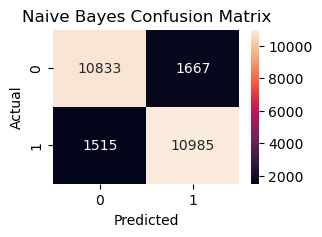

In [10]:

nb_pred = best_nb.predict(X_test)
nb_prob = best_nb.predict_proba(X_test)[:, 1]

print("NB Accuracy:", accuracy_score(y_test, nb_pred))
print("NB F1:", f1_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

cm = confusion_matrix(y_test, nb_pred)
plt.figure(figsize=(3,2))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()
